# **A Cohort-Based Customer Retention Analysis for E-Commerce Growth**

#**Objective**:
This project uses cohort analysis on e-commerce data to measure customer retention, compare loyalty patterns between Corporate and Consumer segments, and identify which income group delivers the most sustainable profit over time.

# **1. Import Library**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# **2. Data Loading and Preprocessing**

In [ ]:
df_customers = pd.read_csv('/content/drive/MyDrive/Xom Analytics class/Buoi 6 Cohort analysis/Buoi 6 HW/Customer (1).csv')

In [ ]:
df_ecomsales = pd.read_csv('/content/drive/MyDrive/Xom Analytics class/Buoi 6 Cohort analysis/Buoi 6 HW/EcomSales (2).csv')
df_products = pd.read_csv('/content/drive/MyDrive/Xom Analytics class/Buoi 6 Cohort analysis/Buoi 6 HW/Product (3).csv')
df_region = pd.read_csv('/content/drive/MyDrive/Xom Analytics class/Buoi 6 Cohort analysis/Buoi 6 HW/Region (1).csv')

In [ ]:
print("df_ecomsales head:")
print(df_ecomsales.head())
print("\ndf_customers head:")
print(df_customers.head())
print("\ndf_products head:")
print(df_products.head())
print("\ndf_region head:")
print(df_region.head())

df_ecomsales head:
   RowID                 OrderID  OrderDate CustomerID        Segment  \
0  25221  IN-2012-TH211151-41003 2020-04-04  TH-211151      Corporate   
1  29464  ID-2013-BD116051-41518 2021-09-01  BD-116051       Consumer   
2  27311  IN-2015-TS212051-42173 2023-06-18  TS-212051      Corporate   
3  28882  IN-2014-SU206651-41899 2022-09-17  SU-206651  Self-Employed   
4  27992  IN-2015-GM144551-42217 2023-08-01  GM-144551  Self-Employed   

  RegionCode ProductCode  Quantity  Sales  Discount  Profit  
0    RRR0001     P000001        13    416       0.0   208.0  
1      R0002   PPP000002         4     20       0.0    10.0  
2      R0003     P000003         2     20       0.0     8.0  
3      R0003     P000004         4    556       0.0    55.6  
4      R0003     P000005         2      6       0.0     0.6  

df_customers head:
  CustomerID  FirstName LastName  BirthDate MaritalStatus Gender  \
0  TH-211151        Jon    Huang  6/18/1962             M      M   
1  BD-116051  

In [ ]:
df_ecomsales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   RowID        51290 non-null  int64  
 1   OrderID      51290 non-null  object 
 2   OrderDate    51290 non-null  object 
 3   CustomerID   51290 non-null  object 
 4   Segment      51290 non-null  object 
 5   RegionCode   51290 non-null  object 
 6   ProductCode  51290 non-null  object 
 7   Quantity     51290 non-null  int64  
 8   Sales        51290 non-null  int64  
 9   Discount     51290 non-null  float64
 10  Profit       51290 non-null  float64
dtypes: float64(2), int64(3), object(6)
memory usage: 4.3+ MB


In [ ]:
df_ecomsales.duplicated().sum()

np.int64(0)

In [ ]:
df_ecomsales.isna().sum()

,0
RowID,0
OrderID,0
OrderDate,0
CustomerID,0
Segment,0
RegionCode,0
ProductCode,0
Quantity,0
Sales,0
Discount,0


In [ ]:
df_ecomsales['OrderDate'] = df_ecomsales['OrderDate'].astype('datetime64[ns]')

# **3. Cohort Retention Analysis (2022)**

## **3.1. Cohort Setup**

Step 1: Get Acquisition Month (first order ever, all years)

In [ ]:
df_pre_cohort= df_ecomsales[['OrderDate','CustomerID']].dropna(subset = 'CustomerID').reset_index(drop = True)
df_pre_cohort.head()

,OrderDate,CustomerID
0,2020-04-04,TH-211151
1,2021-09-01,BD-116051
2,2023-06-18,TS-212051
3,2022-09-17,SU-206651
4,2023-08-01,GM-144551


In [ ]:
# Min order date per customer across ALL years
df_min_order = df_ecomsales.groupby(by='CustomerID', as_index=False).agg(
    first_datetime=('OrderDate', 'min')
)
df_min_order['first_month'] = df_min_order['first_datetime'].dt.to_period('M')
df_min_order

,CustomerID,first_datetime,first_month
0,AA-10315102,2020-07-03,2020-07
1,AA-10315120,2021-05-16,2021-05
2,AA-10315139,2022-09-19,2022-09
3,AA-103151402,2022-03-04,2022-03
4,AA-103151404,2020-03-30,2020-03
...,...,...,...
17410,ZD-2192548,2020-11-21,2020-11
17411,ZD-2192564,2020-02-21,2020-02
17412,ZD-219257,2020-09-19,2020-09
17413,ZD-2192582,2021-11-26,2021-11


In [ ]:
df_pre_cohort_merge = df_min_order.merge(df_pre_cohort, on='CustomerID', how='inner')
df_pre_cohort_merge.head()

,CustomerID,first_datetime,first_month,OrderDate
0,AA-10315102,2020-07-03,2020-07,2023-01-07
1,AA-10315102,2020-07-03,2020-07,2020-07-03
2,AA-10315102,2020-07-03,2020-07,2020-07-03
3,AA-10315102,2020-07-03,2020-07,2020-07-03
4,AA-10315102,2020-07-03,2020-07,2023-01-07


In [ ]:
# Calculate month difference (cohort index)
df_pre_cohort_merge['month_diff'] = (
    (df_pre_cohort_merge['OrderDate'].dt.year - df_pre_cohort_merge['first_datetime'].dt.year) * 12
    + (df_pre_cohort_merge['OrderDate'].dt.month - df_pre_cohort_merge['first_datetime'].dt.month)
)
df_pre_cohort_merge.head()

,CustomerID,first_datetime,first_month,OrderDate,month_diff
0,AA-10315102,2020-07-03,2020-07,2023-01-07,30
1,AA-10315102,2020-07-03,2020-07,2020-07-03,0
2,AA-10315102,2020-07-03,2020-07,2020-07-03,0
3,AA-10315102,2020-07-03,2020-07,2020-07-03,0
4,AA-10315102,2020-07-03,2020-07,2023-01-07,30


In [ ]:
# Filter for customers whose first order ever was in 2022
df_cohort_analysis = df_pre_cohort_merge[df_pre_cohort_merge['first_datetime'].dt.year == 2022].copy()

# Further filter to only include orders made in 2022 for these specific cohorts
df_cohort_analysis = df_cohort_analysis[df_cohort_analysis['OrderDate'].dt.year == 2022]

df_cohort_analysis.sort_values(by='month_diff', ascending=False).head()

,CustomerID,first_datetime,first_month,OrderDate,month_diff
48435,TG-216407,2022-01-18,2022-01,2022-12-18,11
48437,TG-216407,2022-01-18,2022-01,2022-12-18,11
35181,MV-181907,2022-01-07,2022-01,2022-11-23,10
48956,TP-2113045,2022-02-28,2022-02,2022-12-02,10
45202,SM-10005108,2022-01-12,2022-01,2022-11-15,10


In [ ]:
df_cohort = df_cohort_analysis.pivot_table(
    values='CustomerID',
    index='first_month',
    columns='month_diff',
    aggfunc='nunique'
)
df_cohort

month_diff,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,252.0,1.0,1.0,4.0,4.0,3.0,4.0,6.0,7.0,4.0,9.0,1.0
2022-02,214.0,4.0,2.0,5.0,1.0,2.0,7.0,5.0,5.0,5.0,3.0,NaN
2022-03,290.0,2.0,5.0,4.0,4.0,9.0,10.0,3.0,7.0,13.0,NaN,NaN
2022-04,258.0,1.0,5.0,2.0,3.0,5.0,3.0,6.0,7.0,NaN,NaN,NaN
2022-05,352.0,7.0,7.0,10.0,8.0,5.0,7.0,13.0,NaN,NaN,NaN,NaN
2022-06,517.0,6.0,17.0,13.0,6.0,6.0,17.0,NaN,NaN,NaN,NaN,NaN
2022-07,292.0,8.0,8.0,4.0,6.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN
2022-08,442.0,13.0,9.0,6.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,518.0,9.0,15.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **3.2 Cohort Visualization**

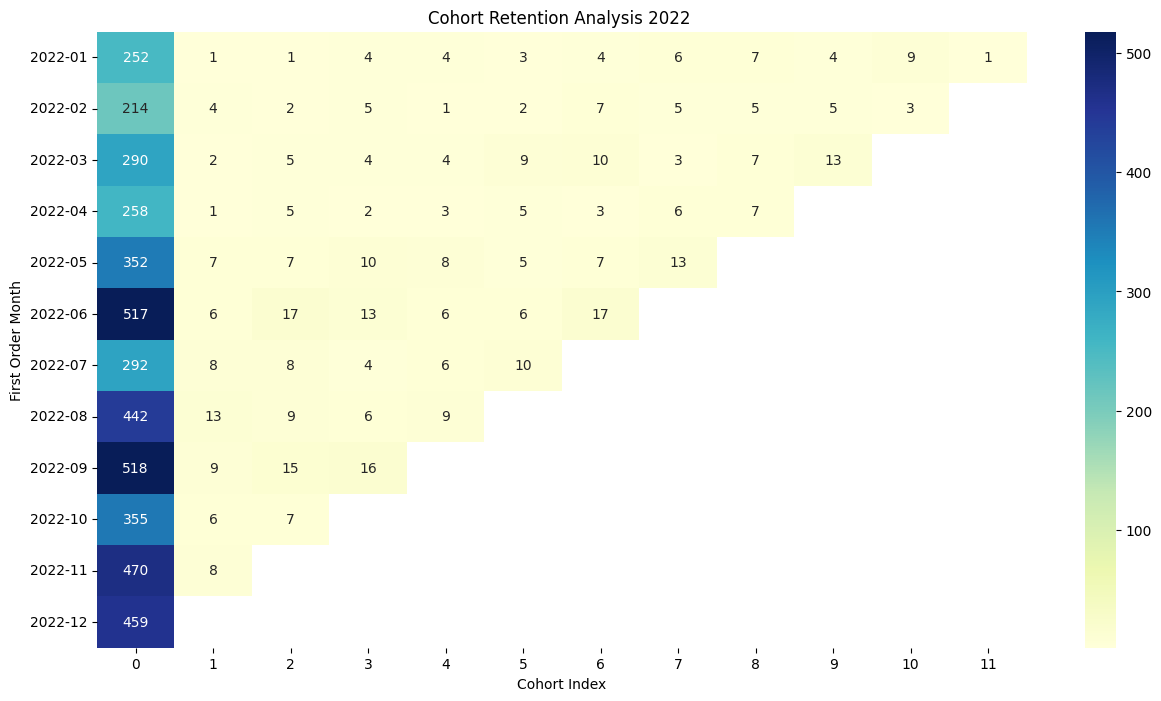

In [ ]:
plt.figure(figsize= (15,8))
sns.heatmap(data = df_cohort
            ,annot=True
            ,cmap='YlGnBu'
            ,fmt = 'g'
            )
plt.xlabel('Cohort Index')
plt.ylabel('First Order Month')
plt.title('Cohort Retention Analysis 2022 ')
plt.show()

In [ ]:
df_retention = df_cohort.divide(df_cohort.iloc[:,0], axis = 0)
df_retention.head()

month_diff,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,1.0,0.003968,0.003968,0.015873,0.015873,0.011905,0.015873,0.023810,0.027778,0.015873,0.035714,0.003968
2022-02,1.0,0.018692,0.009346,0.023364,0.004673,0.009346,0.032710,0.023364,0.023364,0.023364,0.014019,NaN
2022-03,1.0,0.006897,0.017241,0.013793,0.013793,0.031034,0.034483,0.010345,0.024138,0.044828,NaN,NaN
2022-04,1.0,0.003876,0.019380,0.007752,0.011628,0.019380,0.011628,0.023256,0.027132,NaN,NaN,NaN
2022-05,1.0,0.019886,0.019886,0.028409,0.022727,0.014205,0.019886,0.036932,NaN,NaN,NaN,NaN


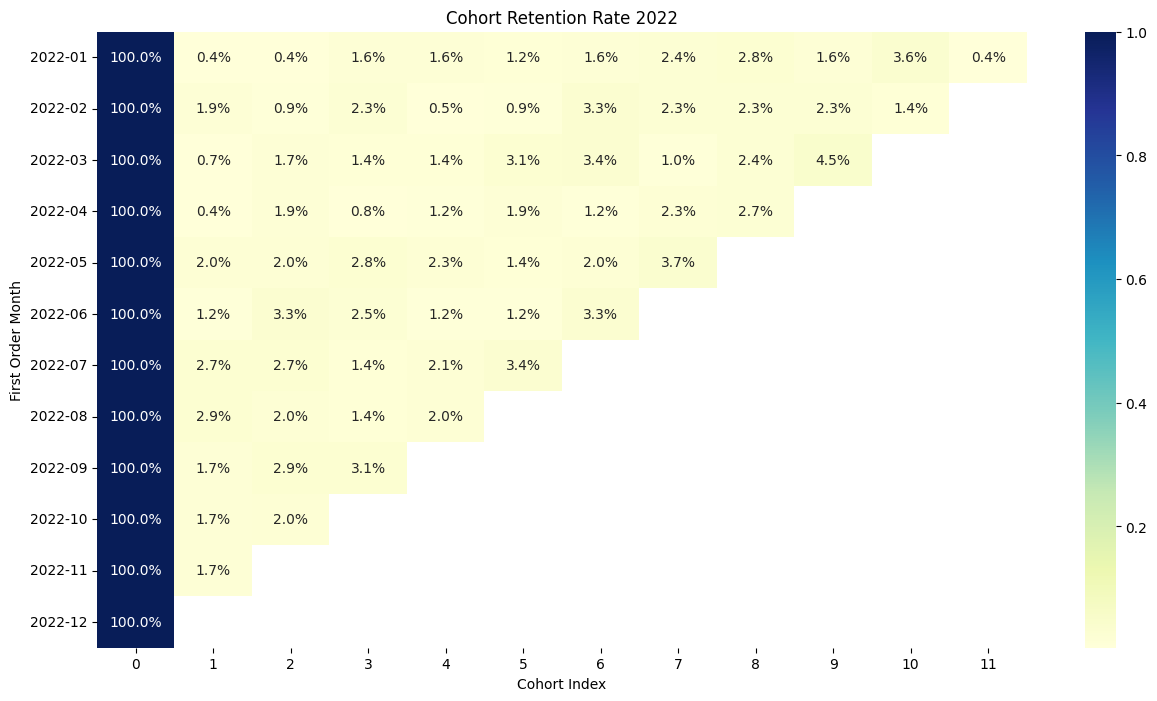

In [ ]:
plt.figure(figsize = (15,8))
sns.heatmap(data = df_retention
            ,annot = True
            ,fmt = '.1%'
            ,cmap = 'YlGnBu'
           )
plt.xlabel('Cohort Index')
plt.ylabel('First Order Month')
plt.title('Cohort Retention Rate 2022')
plt.show()

In [ ]:
# Fresh copy from original cohort
df_cohort_plot = df_cohort.copy()

# Get cohort size from column 0 (Month 0)
cohort_size_plot = df_cohort_plot[0]

# Calculate retention matrix
retention_plot = df_cohort_plot.divide(cohort_size_plot, axis=0)

# Drop all accidentally created columns, keep only cohort index columns (integers)
cols_to_drop = [col for col in retention_plot.columns if not isinstance(col, int)]
retention_plot = retention_plot.drop(columns=cols_to_drop)

# Now re-add #Customers cleanly as NaN
retention_plot.insert(loc=0, column='#Customers', value=float('nan'))

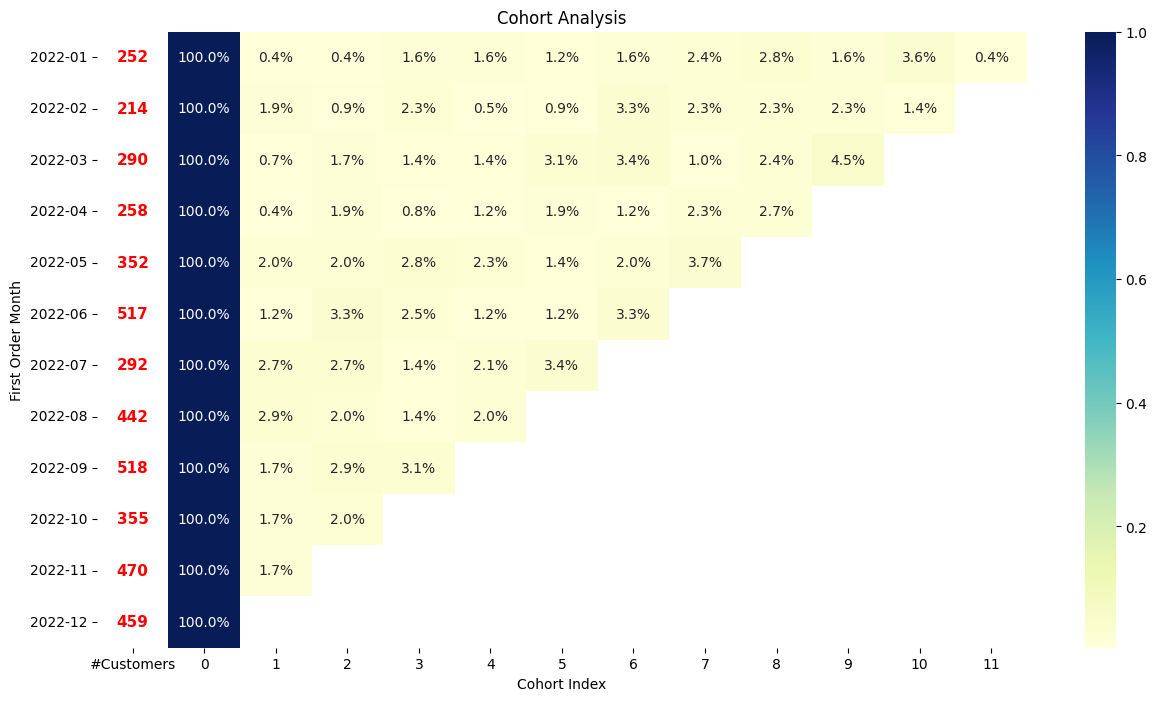

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(data=retention_plot,
            annot=True,
            cmap='YlGnBu',
            fmt='.1%',
            mask=retention_plot.isna())

# Overlay actual customer counts in red on the #Customers column
for i in range(len(cohort_size_plot)):
    plt.text(0.5, i + 0.5, '{:,.0f}'.format(cohort_size_plot.iloc[i]),
             ha='center', va='center', color='red', fontweight='bold', fontsize=11)

plt.xlabel('Cohort Index')
plt.ylabel('First Order Month')
plt.title('Cohort Analysis')
plt.show()

## **3.3 Key Findings & Insights**

***Cohort Sizes***

Largest cohorts: **Sep 2022 (518), Jun 2022 (517), Nov 2022 (470)** — suggesting strong customer acquisition mid-to-late year
**Smallest cohort: Jan 2022 (252)**

***Retention Rates***

**Month 1 retention is very low** across all cohorts — averaging around 1–3%, which means **most customers do not come back the very next month**

Retention gradually improves at **Month 3–6**, suggesting customers tend to **return on a quarterly** purchase cycle rather than monthly
The Jan 2022 cohort shows the h**ighest long-term retention at Month 10 (3.57%)** — they've had the most time to return

***Overall Pattern***

This looks like a **low-frequency, non-subscription e-commerce business** — customers don't shop every month, which is normal for general merchandise
The average retention curve stays between 1–4% after Month 0, consistent across all cohorts



# **4. Cohort Segment Analysis (Corporate vs. Consumer)?**

## **4.1 Cohort Set Up**

In [ ]:
df_merged_with_segment = df_cohort_analysis.merge(df_ecomsales[['CustomerID', 'Segment']], on='CustomerID', how='inner')
df_merged_with_segment.head()

,CustomerID,first_datetime,first_month,OrderDate,month_diff,Segment
0,AA-10315139,2022-09-19,2022-09,2022-09-19,0,Consumer
1,AA-10315139,2022-09-19,2022-09,2022-09-19,0,Consumer
2,AA-10315139,2022-09-19,2022-09,2022-09-19,0,Consumer
3,AA-10315139,2022-09-19,2022-09,2022-09-19,0,Consumer
4,AA-10315139,2022-09-19,2022-09,2022-09-19,0,Consumer


In [ ]:
# Split by segment
df_corporate = df_merged_with_segment[df_merged_with_segment['Segment'] == 'Corporate']
df_consumer  = df_merged_with_segment[df_merged_with_segment['Segment'] == 'Consumer']


In [ ]:
# Function to build cohort pivot
def get_cohort_pivot(df):
    return df.pivot_table(
        values='CustomerID',
        index='first_month',
        columns='month_diff',
        aggfunc='nunique'
    )


In [ ]:
df_cohort_corp = get_cohort_pivot(df_corporate)
df_cohort_corp

month_diff,0,1,2,3,4,5,6,7,8,9,10
first_month,,,,,,,,,,,
2022-01,84.0,NaN,1.0,1.0,1.0,1.0,2.0,2.0,3.0,1.0,3.0
2022-02,68.0,2.0,NaN,1.0,1.0,NaN,1.0,3.0,NaN,NaN,1.0
2022-03,77.0,2.0,1.0,1.0,1.0,2.0,1.0,NaN,2.0,2.0,NaN
2022-04,74.0,NaN,1.0,1.0,1.0,2.0,NaN,1.0,2.0,NaN,NaN
2022-05,94.0,4.0,4.0,2.0,5.0,3.0,3.0,5.0,NaN,NaN,NaN
2022-06,158.0,1.0,9.0,5.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN
2022-07,94.0,2.0,2.0,2.0,2.0,5.0,NaN,NaN,NaN,NaN,NaN
2022-08,138.0,4.0,4.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,162.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_cohort_cons = get_cohort_pivot(df_consumer)
df_cohort_cons

month_diff,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,122.0,NaN,NaN,NaN,1.0,2.0,1.0,4.0,4.0,2.0,3.0,1.0
2022-02,112.0,2.0,2.0,4.0,NaN,2.0,5.0,2.0,2.0,4.0,2.0,NaN
2022-03,153.0,NaN,3.0,2.0,3.0,5.0,8.0,2.0,3.0,8.0,NaN,NaN
2022-04,129.0,1.0,2.0,1.0,1.0,2.0,3.0,3.0,4.0,NaN,NaN,NaN
2022-05,200.0,2.0,2.0,7.0,3.0,1.0,4.0,7.0,NaN,NaN,NaN,NaN
2022-06,240.0,4.0,7.0,5.0,5.0,3.0,12.0,NaN,NaN,NaN,NaN,NaN
2022-07,136.0,4.0,3.0,2.0,3.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2022-08,223.0,5.0,2.0,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,251.0,7.0,9.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **4.2 Cohort Visualization**

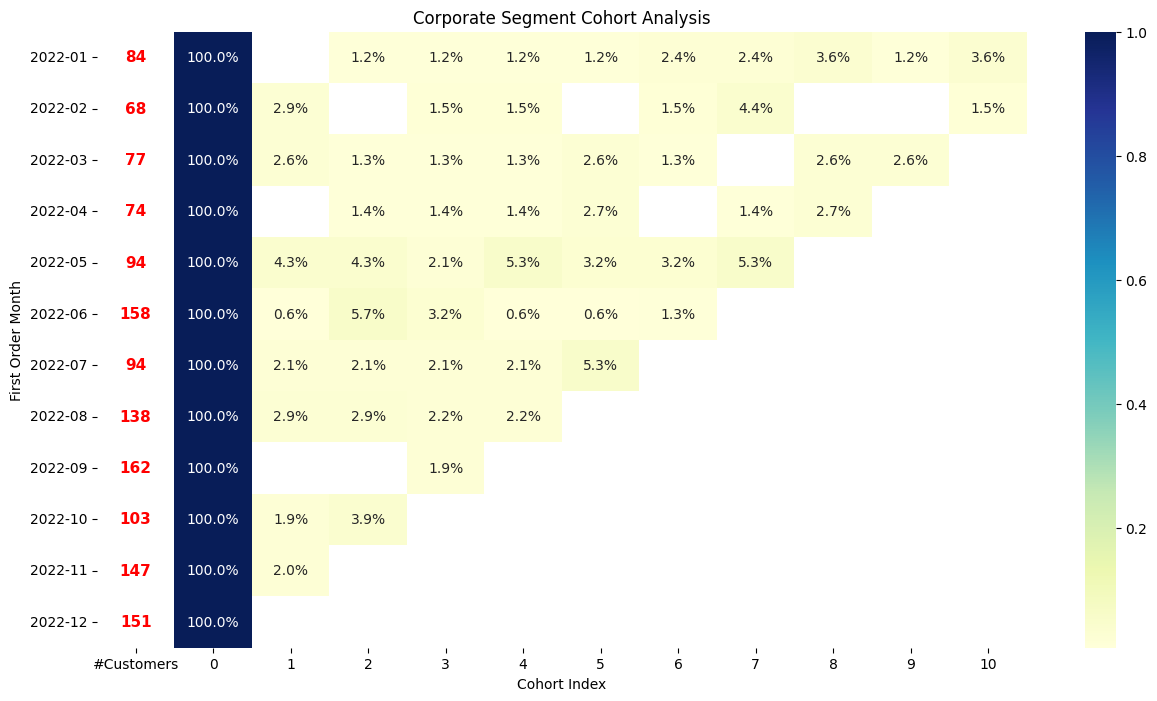

In [ ]:
df_cohort_corp_plot = df_cohort_corp.copy()

# Get cohort size from column 0 (Month 0)
cohort_size_corp = df_cohort_corp_plot[0]

# Calculate retention matrix
retention_corp = df_cohort_corp_plot.divide(cohort_size_corp, axis=0)

# Now re-add #Customers cleanly as NaN
retention_corp.insert(loc=0, column='#Customers', value=float('nan'))

plt.figure(figsize=(15, 8))
sns.heatmap(data=retention_corp,
            annot=True,
            cmap='YlGnBu',
            fmt='.1%',
            mask=retention_corp.isna())

# Overlay actual customer counts in red on the #Customers column
for i in range(len(cohort_size_corp)):
    plt.text(0.5, i + 0.5, '{:,.0f}'.format(cohort_size_corp.iloc[i]),
             ha='center', va='center', color='red', fontweight='bold', fontsize=11)

plt.xlabel('Cohort Index')
plt.ylabel('First Order Month')
plt.title('Corporate Segment Cohort Analysis')
plt.show()

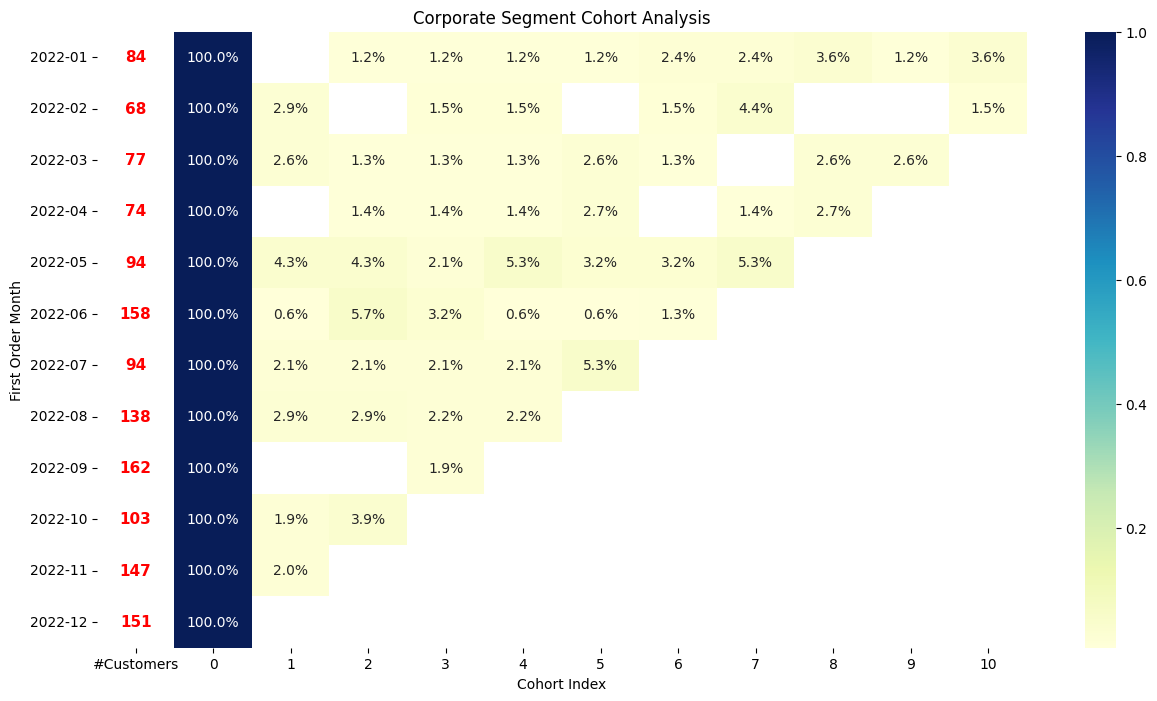

In [ ]:
df_cohort_corp_plot = df_cohort_corp.copy()

# Get cohort size from column 0 (Month 0)
cohort_size_corp = df_cohort_corp_plot[0]

# Calculate retention matrix
retention_corp = df_cohort_corp_plot.divide(cohort_size_corp, axis=0)

retention_corp.insert(loc=0, column='#Customers', value=float('nan'))

plt.figure(figsize=(15, 8))
sns.heatmap(data=retention_corp,
            annot=True,
            cmap='YlGnBu',
            fmt='.1%',
            mask=retention_corp.isna())

# Overlay actual customer counts in red on the #Customers column
for i in range(len(cohort_size_corp)):
    plt.text(0.5, i + 0.5, '{:,.0f}'.format(cohort_size_corp.iloc[i]),
             ha='center', va='center', color='red', fontweight='bold', fontsize=11)

plt.xlabel('Cohort Index')
plt.ylabel('First Order Month')
plt.title('Corporate Segment Cohort Analysis')
plt.show()

## **4.3 Key Findings & Insights**

**1. Corporate retains better short-term (Month 1–2)**
Corporate customers return faster after acquisition — May 2022 cohort reaches 4.3% at Month 1, compared to Consumer's best of 2.9% (July). This likely reflects recurring business procurement behavior rather than personal shopping decisions.

**2. Consumer overtakes at Month 5–6**
Consumer cohorts show stronger late-stage retention, with March 2022 reaching 5.2% at both Month 5 and Month 9. Once re-engaged, Consumer customers tend to stay active longer than their Corporate counterparts.

**3. Corporate return pattern is more irregular**
Corporate shows more scattered blank cells across the matrix, indicating unpredictable purchase timing. Consumer retention, while similarly low, is more evenly distributed across months.

**4. Both segments follow a quarterly purchase cycle**
Neither segment shops monthly. Retention peaks consistently appear at Month 3 and Month 5–6 for both groups, confirming that a **60–90 day re-engagement window** is the natural rhythm of this e-commerce business.

> **Strategic Takeaway:** Apply 30-day follow-up campaigns for Corporate to capitalize on short-term return intent. Use 90-day re-engagement sequences for Consumer to target their longer activation window.

# **5. Income Group Analysis**

## **5.1 Cohort Setup**

In [ ]:
df_income = df_cohort_analysis.merge(
    df_ecomsales[['CustomerID', 'Profit']].merge(
        df_customers[['CustomerID', 'AnnualIncome']], on='CustomerID', how='left'
    ),
    on='CustomerID', how='left'
)
df_income.head()

,CustomerID,first_datetime,first_month,OrderDate,month_diff,Profit,AnnualIncome
0,AA-10315139,2022-09-19,2022-09,2022-09-19,0,18.00,30000
1,AA-10315139,2022-09-19,2022-09,2022-09-19,0,11.20,30000
2,AA-10315139,2022-09-19,2022-09,2022-09-19,0,-1.50,30000
3,AA-10315139,2022-09-19,2022-09,2022-09-19,0,2.40,30000
4,AA-10315139,2022-09-19,2022-09,2022-09-19,0,2.85,30000


In [ ]:
min_income = df_customers['AnnualIncome'].min()
max_income = df_customers['AnnualIncome'].max()
print(f"Income Range: ${min_income:,.0f} - ${max_income:,.0f}")

Income Range: $10,000 - $170,000


Customers are divided into three income bands based on Annual Income distribution:
- **Low:** Below $40,000

- **Mid:** 40,000 - $90,000

- **High:** Above $90,000

In [ ]:
# Assign income bands
def assign_income_band(income):
    if income < 40000:
        return 'Low'
    elif income <= 90000:
        return 'Mid'
    else:
        return 'High'

df_income['IncomeBand'] = df_income['AnnualIncome'].apply(assign_income_band)
df_income

,CustomerID,first_datetime,first_month,OrderDate,month_diff,Profit,AnnualIncome,IncomeBand
0,AA-10315139,2022-09-19,2022-09,2022-09-19,0,18.00,30000,Low
1,AA-10315139,2022-09-19,2022-09,2022-09-19,0,11.20,30000,Low
2,AA-10315139,2022-09-19,2022-09,2022-09-19,0,-1.50,30000,Low
3,AA-10315139,2022-09-19,2022-09,2022-09-19,0,2.40,30000,Low
4,AA-10315139,2022-09-19,2022-09,2022-09-19,0,2.85,30000,Low
...,...,...,...,...,...,...,...,...
40295,ZD-219251408,2022-05-06,2022-05,2022-05-06,0,-5.00,40000,Mid
40296,ZD-219251408,2022-05-06,2022-05,2022-07-09,2,4.80,40000,Mid
40297,ZD-219251408,2022-05-06,2022-05,2022-07-09,2,-3.50,40000,Mid
40298,ZD-219251408,2022-05-06,2022-05,2022-07-09,2,-5.00,40000,Mid


In [ ]:
# Check distribution
df_income.groupby('IncomeBand')['CustomerID'].nunique()

,CustomerID
IncomeBand,
High,517
Low,1248
Mid,2654


In [ ]:
df_low  = df_income[df_income['IncomeBand'] == 'Low']
df_mid  = df_income[df_income['IncomeBand'] == 'Mid']
df_high = df_income[df_income['IncomeBand'] == 'High']

In [ ]:
df_high

,CustomerID,first_datetime,first_month,OrderDate,month_diff,Profit,AnnualIncome,IncomeBand
255,AB-1001545,2022-08-13,2022-08,2022-10-18,2,45.15,110000,High
256,AB-1001545,2022-08-13,2022-08,2022-10-18,2,2.40,110000,High
257,AB-1001545,2022-08-13,2022-08,2022-10-18,2,60.00,110000,High
258,AB-1001545,2022-08-13,2022-08,2022-10-18,2,-2.10,110000,High
259,AB-1001545,2022-08-13,2022-08,2022-10-18,2,-3.00,110000,High
...,...,...,...,...,...,...,...,...
40105,VW-2177527,2022-07-16,2022-07,2022-07-16,0,8.10,130000,High
40106,VW-2177527,2022-07-16,2022-07,2022-07-16,0,40.00,130000,High
40107,VW-2177527,2022-07-16,2022-07,2022-07-16,0,54.60,130000,High
40108,VW-2177527,2022-07-16,2022-07,2022-07-16,0,12.10,130000,High


In [ ]:
df_cohort_low  = df_low.pivot_table(values='CustomerID', index='first_month', columns='month_diff', aggfunc='nunique')
df_cohort_mid  = df_mid.pivot_table(values='CustomerID', index='first_month', columns='month_diff', aggfunc='nunique')
df_cohort_high = df_high.pivot_table(values='CustomerID', index='first_month', columns='month_diff', aggfunc='nunique')

In [ ]:
df_cohort_high

month_diff,0,1,2,3,4,5,6,7,8,9,10
first_month,,,,,,,,,,,
2022-01,29.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,2.0
2022-02,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
2022-03,31.0,NaN,1.0,1.0,2.0,NaN,NaN,NaN,NaN,2.0,NaN
2022-04,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-05,45.0,1.0,1.0,2.0,2.0,NaN,NaN,3.0,NaN,NaN,NaN
2022-06,61.0,1.0,2.0,3.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN
2022-07,28.0,1.0,1.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN
2022-08,58.0,NaN,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,47.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **5.2 Cohort Visualization**

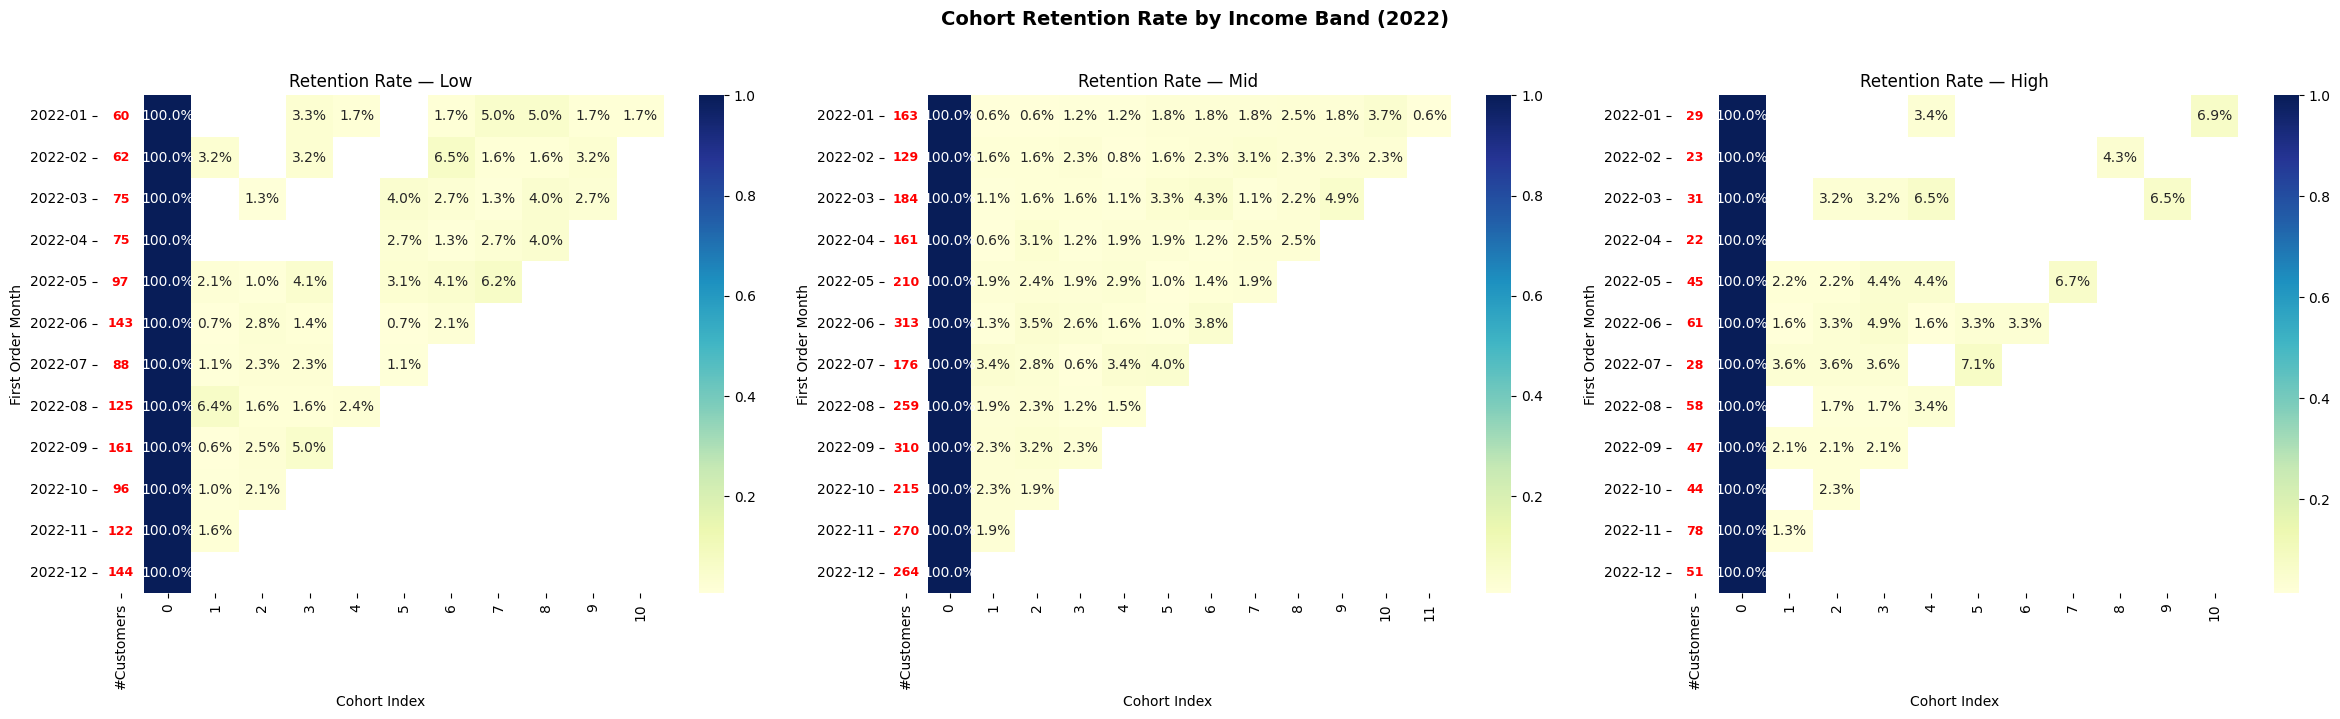

In [ ]:
income_bands  = ['Low',   'Mid',  'High']
cohort_pivots = [df_cohort_low,   df_cohort_mid,      df_cohort_high]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, band, df_cohort_band in zip(axes, income_bands, cohort_pivots):

    # Cohort size
    cohort_size_band = df_cohort_band[0]

    # Retention matrix
    retention_band = df_cohort_band.divide(cohort_size_band, axis=0)
    retention_band.insert(loc=0, column='#Customers', value=float('nan'))

    sns.heatmap(data=retention_band,
                annot=True,
                cmap='YlGnBu',
                fmt='.1%',
                mask=retention_band.isna(),
                ax=ax)

    # Overlay cohort size in red
    for i in range(len(cohort_size_band)):
        ax.text(0.5, i + 0.5, '{:,.0f}'.format(cohort_size_band.iloc[i]),
                ha='center', va='center', color='red', fontweight='bold', fontsize=9)

    ax.set_xlabel('Cohort Index')
    ax.set_ylabel('First Order Month')
    ax.set_title(f'Retention Rate — {band}')

plt.suptitle('Cohort Retention Rate by Income Band (2022)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5.3 Key Findings & Insights

**1. High-income (>$90K) has the strongest retention rate over time**
The smallest group but the most loyal — retention climbs to 6.9% at Month 10
(Jan cohort) and 6.7% at Month 7 (May cohort). The only group where late-stage
retention consistently improves rather than fades.

**2. Mid-income (40K–90K) is the most sustainable in volume**
Largest cohort sizes (129–313 per month) with retention activity visible across
all 11 months. Not the highest rate, but the most **consistent and long-lasting**
presence across the full observation window.

**3. Low-income (<$40K) fades after Month 6**
Decent early retention but activity drops sharply after Month 6 with most cohorts
showing no returns beyond Month 8. Engages early, does not sustain.

> **Mid-income (40K–90K)** delivers the most sustainable profit —
largest base, longest retention window, consistent across all months.
**High-income (>$90K)** shows stronger loyalty rates but is too small in volume
to drive sustainable profit alone. Prioritize **retaining Mid-income** as the
revenue foundation while **growing the High-income base** for long-term upside.